# Форманты

В этой работе оцениваем первые три форманты речевого сигнала: `F1`, `F2`, `F3`.

По условию нужно:
- записать фрагмент речевого сигнала;
- применить метод на основе линейного предсказания;
- построить траектории первых трех формант.

Дополнительно сравниваются разные типы речи и проверяется влияние шума.

---
## Записи

В работе используются четыре записи:

1. `Prosa.mp3` - обычная речь.
2. `whisper.mp3` - шепот.
3. `Первомай-песня.mp3` - пение.
4. `За_гремучую_доблесть_стих.mp3` - стихотворная речь.

Каждая запись приводится к фрагменту около `20 с`.

---
## Что делаем

1. Загружаем записи через `librosa`.
2. Приводим сигнал к моно и частоте `16 кГц`.
3. Режем сигнал на кадры по `25 мс` с шагом `10 мс`.
4. Для каждого кадра считаем коэффициенты линейного предсказания.
5. Находим корни многочлена через `np.roots`.
6. По корням получаем частоты формант и строим траектории `F1`, `F2`, `F3`.
7. Добавляем белый шум к обычной речи и считаем простые метрики.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.facecolor"] = "#f8fafc"
plt.rcParams["axes.edgecolor"] = "#cbd5e1"
plt.rcParams["grid.color"] = "#cbd5e1"

FS = 16_000
TARGET_SEC = 20.0
FRAME_MS = 25.0
HOP_MS = 10.0
LPC_ORDER = 16
PRE_EMPH = 0.97
EPS = 1e-12

FRAME_LEN = int(round(FRAME_MS * 1e-3 * FS))
HOP_LEN = int(round(HOP_MS * 1e-3 * FS))

FORMANT_RANGES = {
    "F1": (90.0, 1200.0),
    "F2": (450.0, 3500.0),
    "F3": (1200.0, 5000.0),
}
FORMANT_COLORS = {
    "F1": "#2563eb",
    "F2": "#16a34a",
    "F3": "#dc2626",
}

BASE_DIR = Path("/home/nikita/Code/MSU/cmc_msu_ml/Rech_Max/Problem4")

print(f"Рабочая папка: {BASE_DIR}")
print(f"Параметры: {FS} Гц, кадр {FRAME_MS:.0f} мс, шаг {HOP_MS:.0f} мс, порядок ЛП {LPC_ORDER}")

Рабочая папка: /home/nikita/Code/MSU/cmc_msu_ml/Rech_Max/Problem4
Параметры: 16000 Гц, кадр 25 мс, шаг 10 мс, порядок ЛП 16


---
## Загрузка записей

Файлы заданы явно. Для каждой записи берется наиболее энергичный фрагмент длиной до `20 с`.

In [2]:
RECORDING_SPECS = [
    {
        "key": "normal",
        "label": "Обычная речь",
        "file": "Prosa.mp3",
    },
    {
        "key": "whisper",
        "label": "Шепот",
        "file": "whisper.mp3",
    },
    {
        "key": "singing",
        "label": "Пение",
        "file": "Первомай-песня.mp3",
    },
    {
        "key": "rap_poem",
        "label": "Стихотворная речь",
        "file": "За_гремучую_доблесть_стих.mp3",
    },
]


def normalize_signal(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)
    peak = np.max(np.abs(x)) if len(x) else 0.0
    if peak > EPS:
        x = x / peak
    return x


def select_energy_window(x: np.ndarray, fs: int, target_sec: float) -> np.ndarray:
    target_len = int(round(target_sec * fs))
    if len(x) <= target_len:
        return x

    win = max(1, int(round(0.10 * fs)))
    hop = win
    frame_count = 1 + (len(x) - win) // hop
    starts = np.arange(frame_count) * hop
    energy = np.array([np.mean(x[s:s + win] ** 2) for s in starts])

    need = max(1, target_len // hop)
    score = np.convolve(energy, np.ones(need), mode="valid")
    best = int(np.argmax(score))
    start = best * hop
    return x[start:start + target_len]


def load_recording(path: Path) -> np.ndarray:
    x, _ = librosa.load(path, sr=FS, mono=True)
    x = select_energy_window(x, FS, TARGET_SEC)
    return normalize_signal(x)


rows = []
recordings = {}
for spec in RECORDING_SPECS:
    path = BASE_DIR / spec["file"]
    x = load_recording(path)
    recordings[spec["key"]] = {
        "label": spec["label"],
        "path": path,
        "x": x,
        "fs": FS,
    }
    rows.append(
        {
            "Тип речи": spec["label"],
            "Файл": path.name,
            "Длительность, с": round(len(x) / FS, 2),
        }
    )

files_table = pd.DataFrame(rows)
display(files_table)

,Тип речи,Файл,"Длительность, с"
0,Обычная речь,Prosa.mp3,20.0
1,Шепот,whisper.mp3,20.0
2,Пение,Первомай-песня.mp3,20.0
3,Стихотворная речь,За_гремучую_доблесть_стих.mp3,20.0


---
## Метод линейного предсказания

В методе линейного предсказания текущий отсчет приближается через несколько предыдущих:

$$
x[n] \approx -\sum_{k=1}^{p} a_k x[n-k].
$$

Коэффициенты `a_k` подбираются так, чтобы ошибка была минимальной. Для этого используется автокорреляционная система:

$$
\sum_{k=1}^{p} a_k R[|i-k|] = -R[i],
\quad i=1,\ldots,p.
$$

После этого строится многочлен:

$$
A(z)=1+a_1z^{-1}+a_2z^{-2}+\ldots+a_pz^{-p}.
$$

Его корни показывают резонансные частоты речевого тракта. Эти частоты и считаются формантами.

---
## Ручная реализация

Основная часть метода ниже написана вручную: кадры, автокорреляция, алгоритм Левинсона-Дурбина, корни и отбор первых трех формант. `librosa` используется для чтения звука и построения спектра.

In [3]:
def pre_emphasis(x: np.ndarray, coeff: float = PRE_EMPH) -> np.ndarray:
    if len(x) == 0:
        return x.copy()
    return np.append(x[0], x[1:] - coeff * x[:-1])


def make_frames(x: np.ndarray, frame_len: int = FRAME_LEN, hop_len: int = HOP_LEN) -> np.ndarray:
    if len(x) < frame_len:
        x = np.pad(x, (0, frame_len - len(x)))

    n_frames = 1 + (len(x) - frame_len) // hop_len
    starts = np.arange(n_frames) * hop_len
    idx = starts[:, None] + np.arange(frame_len)[None, :]
    return x[idx]


def autocorrelation(frame: np.ndarray, order: int) -> np.ndarray:
    corr = np.correlate(frame, frame, mode="full")
    mid = len(frame) - 1
    return corr[mid:mid + order + 1]


def levinson_durbin(r: np.ndarray, order: int) -> tuple[np.ndarray, float]:
    a = np.zeros(order + 1, dtype=np.float64)
    a[0] = 1.0
    err = float(r[0])

    if err <= EPS:
        return a, EPS

    for i in range(1, order + 1):
        acc = r[i]
        if i > 1:
            acc += np.dot(a[1:i], r[i - 1:0:-1])
        k = -acc / (err + EPS)

        new_a = a.copy()
        if i > 1:
            new_a[1:i] = a[1:i] + k * a[i - 1:0:-1]
        new_a[i] = k
        a = new_a

        err *= 1.0 - k * k
        if err <= EPS:
            err = EPS
            break

    return a, float(err)


def lpc_coefficients(frame: np.ndarray, order: int = LPC_ORDER) -> tuple[np.ndarray, float]:
    frame = np.asarray(frame, dtype=np.float64)
    frame = frame - np.mean(frame)
    frame = frame * np.hamming(len(frame))
    r = autocorrelation(frame, order)
    return levinson_durbin(r, order)


def roots_to_formant_candidates(a: np.ndarray, fs: int = FS) -> pd.DataFrame:
    roots = np.roots(a)
    roots = roots[np.imag(roots) >= 0.01]
    roots = roots[(np.abs(roots) > 0.40) & (np.abs(roots) < 1.0)]

    freqs = np.angle(roots) * fs / (2 * np.pi)
    bands = -fs * np.log(np.abs(roots) + EPS) / np.pi

    mask = (
        (freqs >= 70.0)
        & (freqs <= 5000.0)
        & (bands >= 30.0)
        & (bands <= 900.0)
    )

    data = pd.DataFrame(
        {
            "Частота, Гц": freqs[mask],
            "Полоса, Гц": bands[mask],
            "Модуль корня": np.abs(roots[mask]),
        }
    )
    return data.sort_values("Частота, Гц").reset_index(drop=True)


def select_first_three_formants(candidates: pd.DataFrame) -> dict[str, float]:
    out = {name: np.nan for name in FORMANT_RANGES}
    prev = 0.0

    for name, (lo, hi) in FORMANT_RANGES.items():
        part = candidates[
            (candidates["Частота, Гц"] >= lo)
            & (candidates["Частота, Гц"] <= hi)
            & (candidates["Частота, Гц"] >= prev + 80.0)
        ].copy()

        if part.empty:
            continue

        center = 0.5 * (lo + hi)
        part["Оценка"] = part["Полоса, Гц"] + 0.04 * np.abs(part["Частота, Гц"] - center)
        best = part.sort_values("Оценка").iloc[0]
        out[name] = float(best["Частота, Гц"])
        prev = out[name]

    return out


def estimate_frame_formants(frame: np.ndarray, order: int = LPC_ORDER) -> dict[str, float]:
    a, err = lpc_coefficients(frame, order=order)
    candidates = roots_to_formant_candidates(a, fs=FS)
    return select_first_three_formants(candidates)


def nanmedian_smooth(y: np.ndarray, width: int = 7, min_count: int = 2) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64)
    out = np.full_like(y, np.nan)
    half = width // 2

    for i in range(len(y)):
        left = max(0, i - half)
        right = min(len(y), i + half + 1)
        vals = y[left:right]
        vals = vals[np.isfinite(vals)]
        if len(vals) >= min_count:
            out[i] = np.median(vals)
    return out


def analyze_formants(x: np.ndarray) -> dict:
    x = normalize_signal(x)
    x_pre = pre_emphasis(x)

    frames = make_frames(x_pre)
    raw_frames = make_frames(x)
    times = (np.arange(len(frames)) * HOP_LEN + FRAME_LEN / 2) / FS

    rms = np.sqrt(np.mean(raw_frames ** 2, axis=1))
    if len(rms) == 0 or np.max(rms) <= EPS:
        threshold = np.inf
    else:
        threshold = max(np.percentile(rms, 35), 0.015 * np.max(rms))

    formants = {name: np.full(len(frames), np.nan, dtype=np.float64) for name in FORMANT_RANGES}

    for i, frame in enumerate(frames):
        if rms[i] < threshold:
            continue
        values = estimate_frame_formants(frame)
        for name, value in values.items():
            formants[name][i] = value

    smooth = {name: nanmedian_smooth(values, width=7) for name, values in formants.items()}

    return {
        "times": times,
        "rms": rms,
        "threshold": threshold,
        "formants": formants,
        "smooth": smooth,
    }

In [4]:
analysis = {}
for key, item in recordings.items():
    analysis[key] = analyze_formants(item["x"])
    print(f"Готово: {item['label']}")

Готово: Обычная речь


Готово: Шепот


Готово: Пение


Готово: Стихотворная речь


---
## Траектории формант

Для каждой записи строится отдельный график. Сверху показаны траектории `F1`, `F2`, `F3` на спектрограмме, снизу - полосы участков, где соответствующая форманта была найдена.

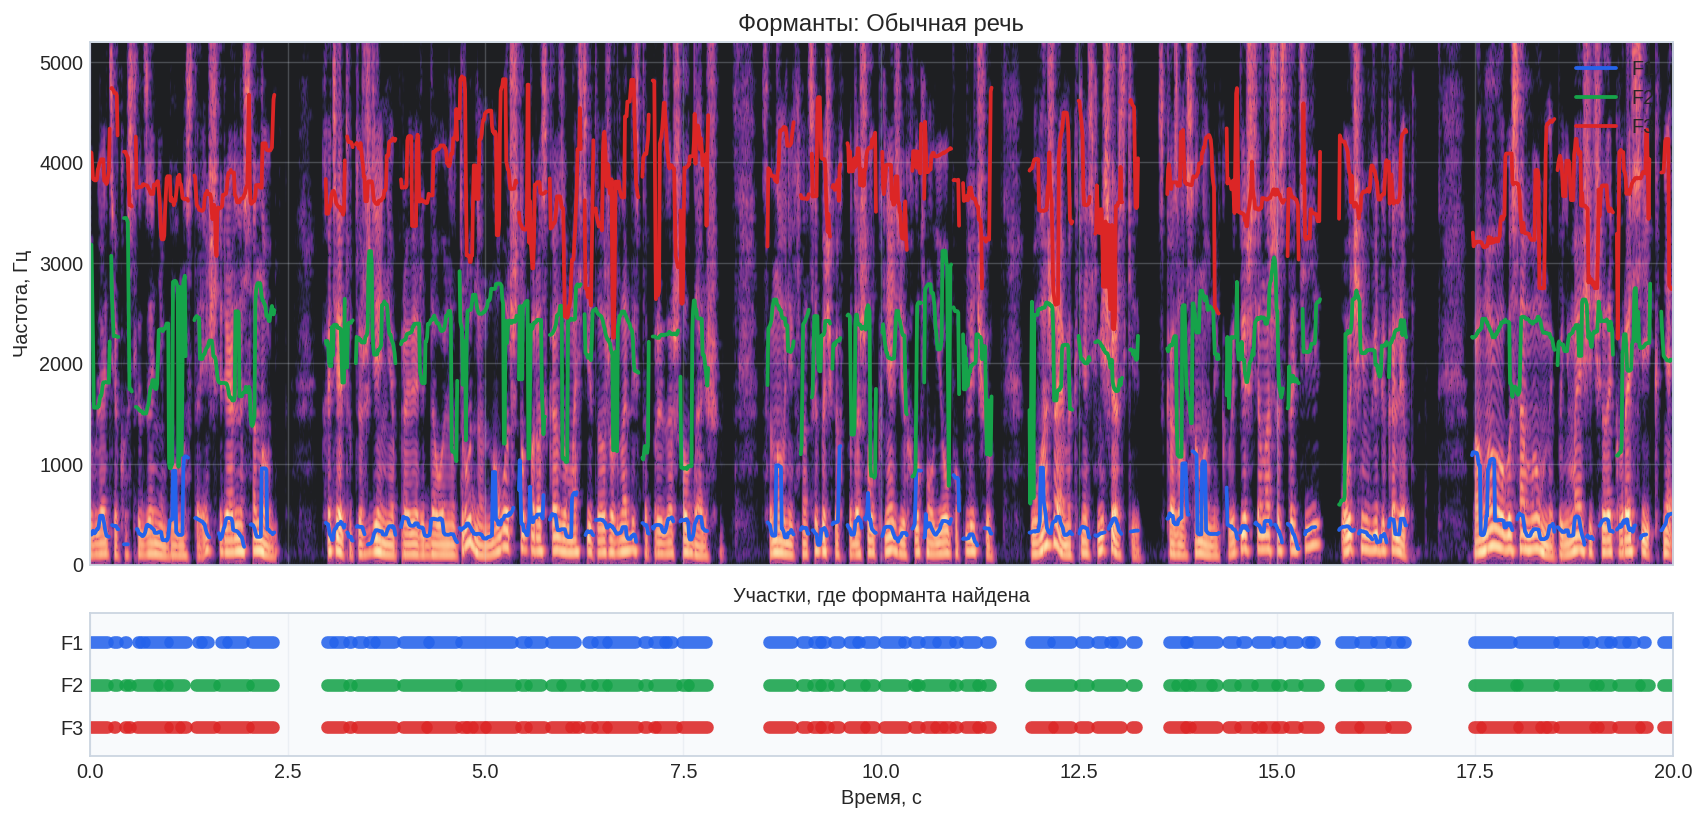

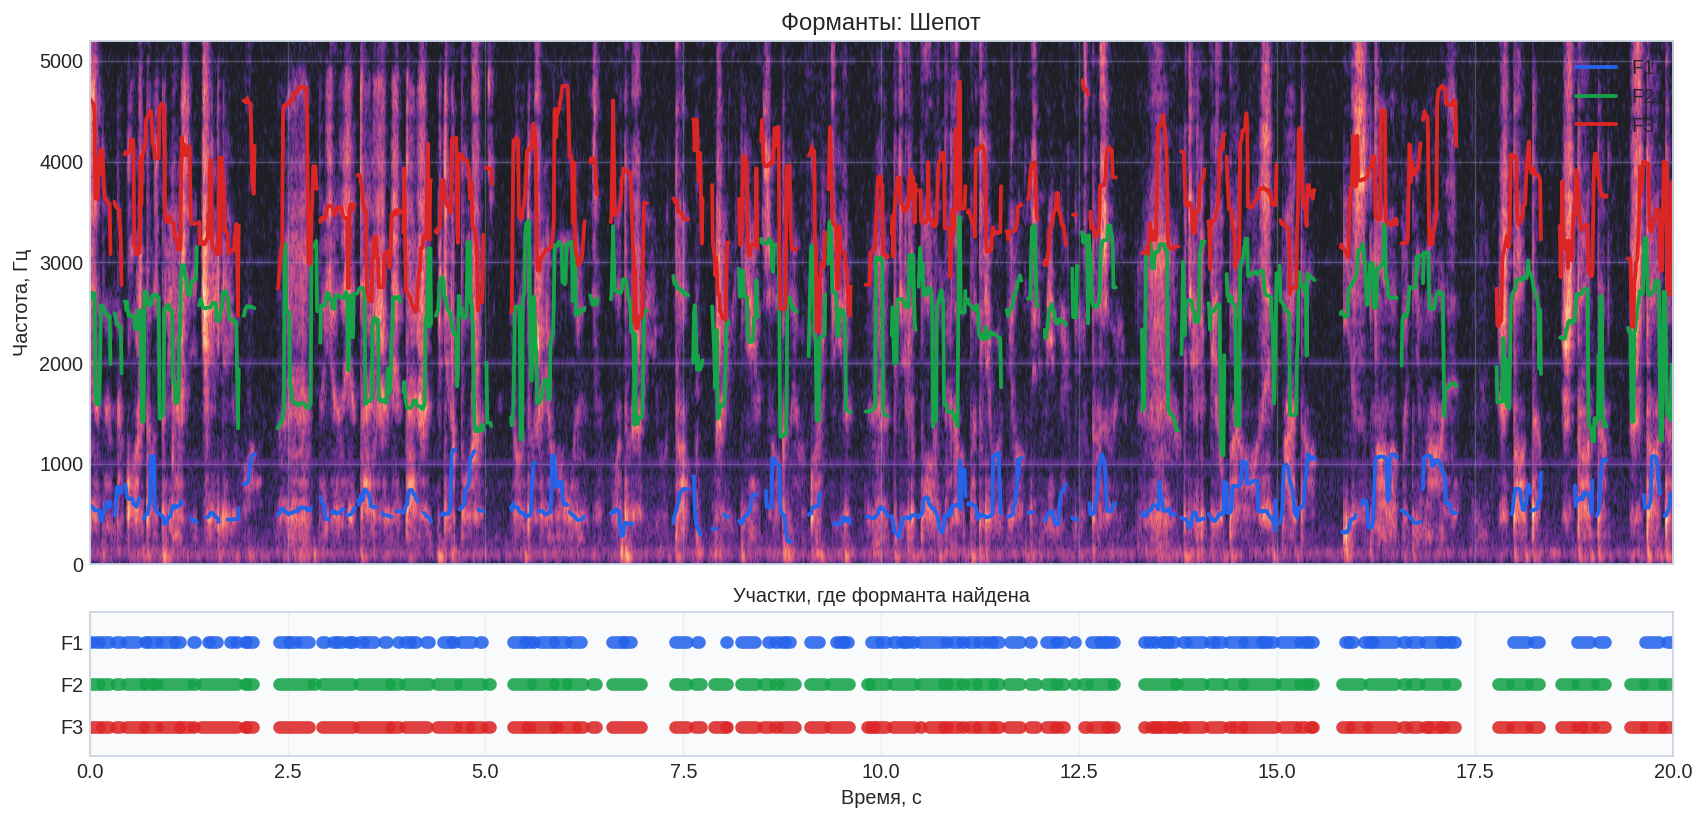

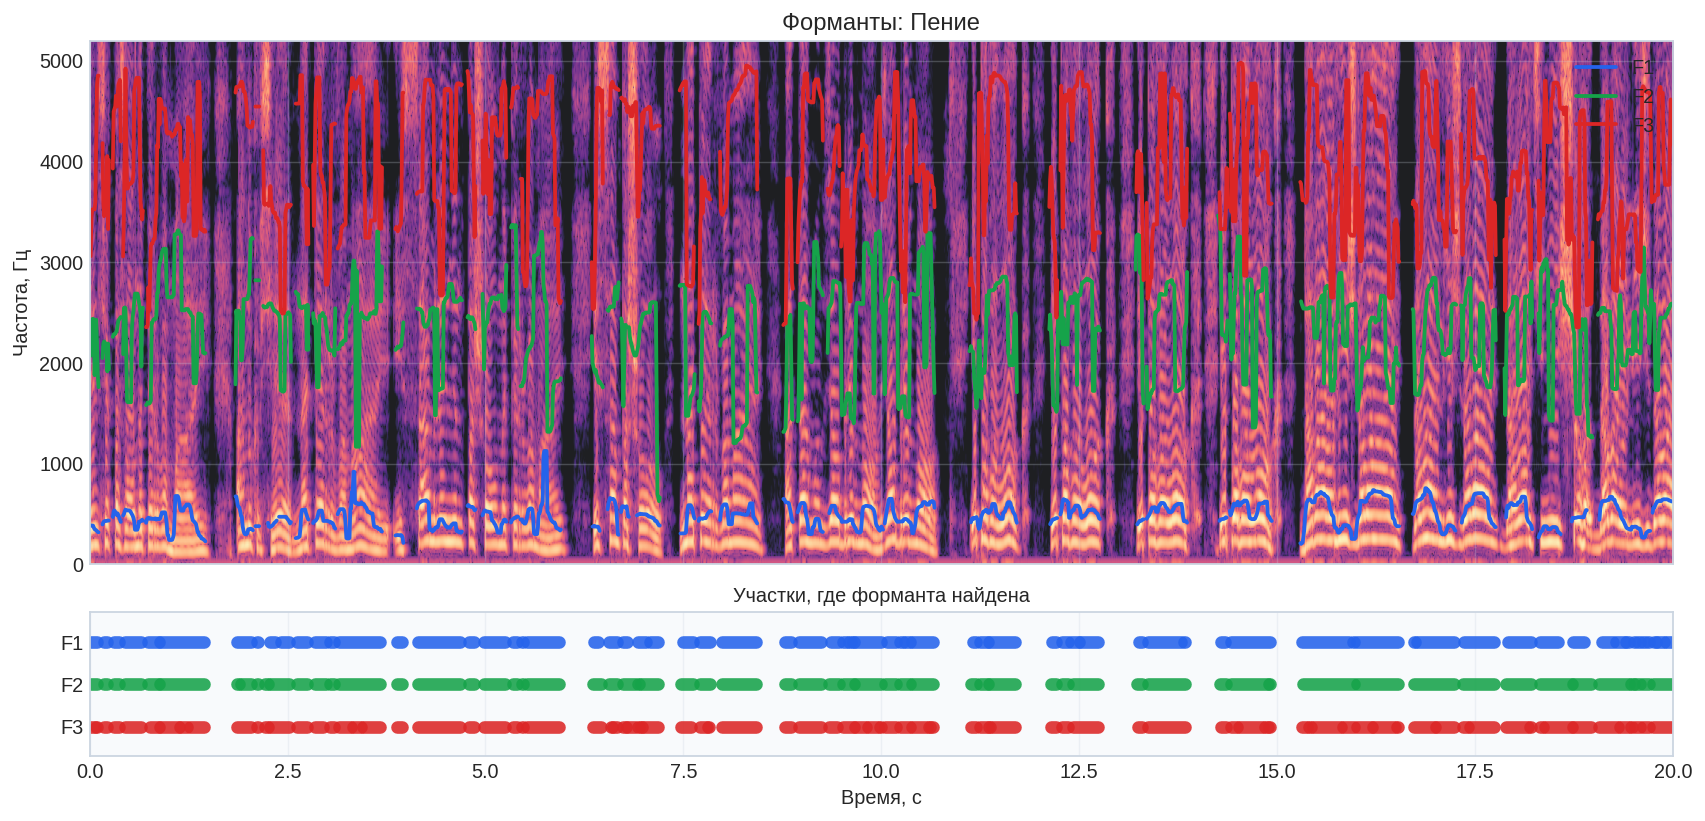

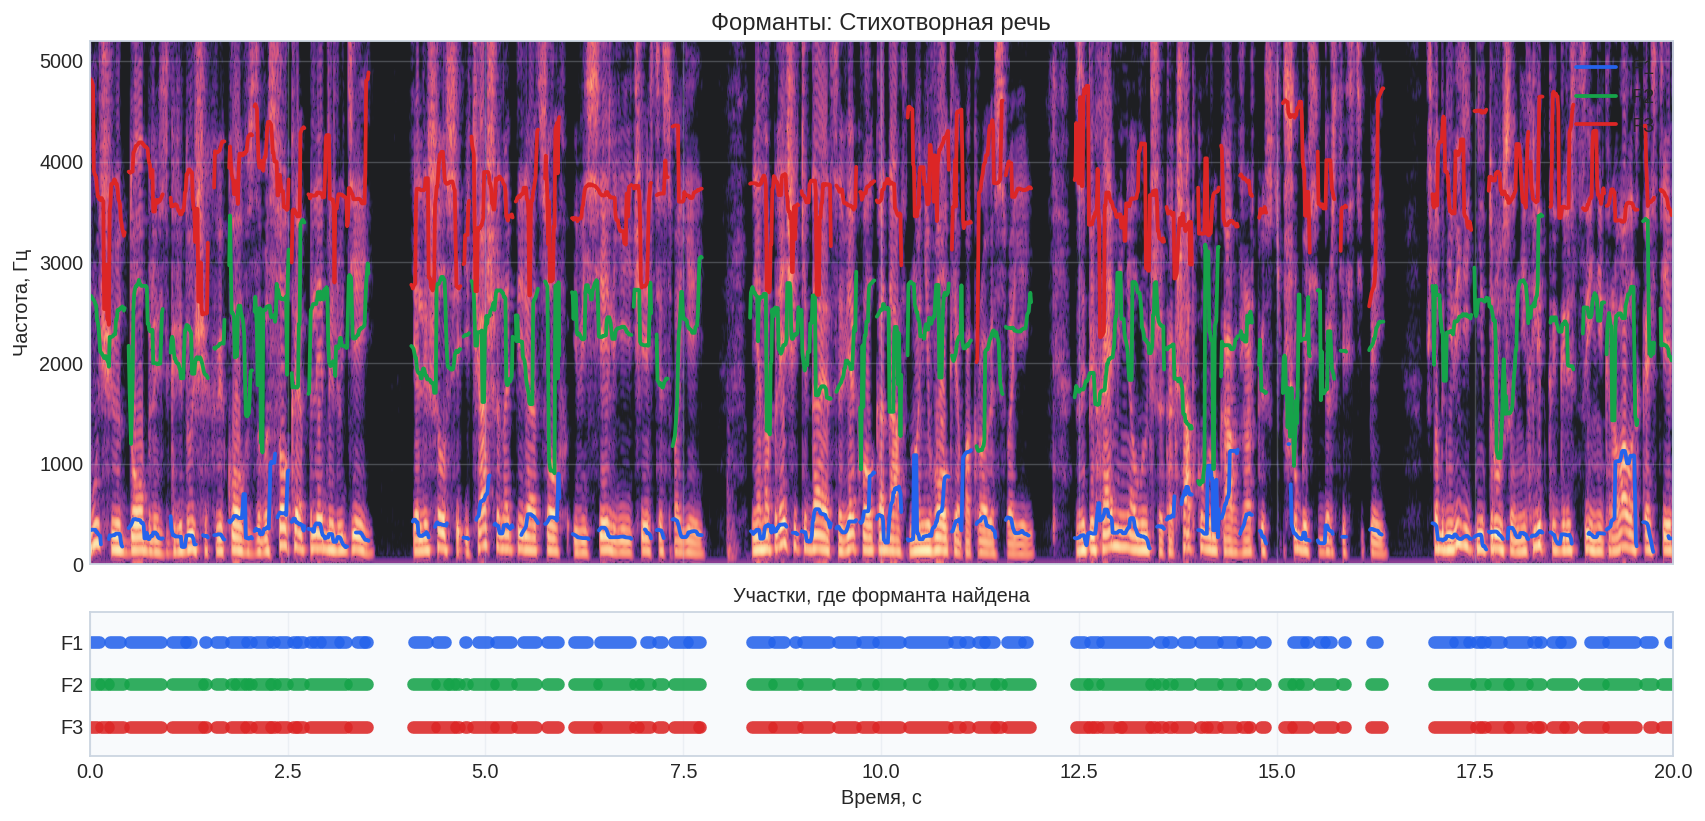

In [5]:
def finite_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    mask = np.asarray(mask, dtype=bool)
    runs = []
    start = None
    for i, ok in enumerate(mask):
        if ok and start is None:
            start = i
        elif not ok and start is not None:
            runs.append((start, i))
            start = None
    if start is not None:
        runs.append((start, len(mask)))
    return runs


def plot_presence_strips(ax, result: dict) -> None:
    names = list(FORMANT_RANGES)
    y_positions = np.arange(len(names))[::-1]

    for y, name in zip(y_positions, names):
        mask = np.isfinite(result["formants"][name])
        shown = False
        for start, end in finite_runs(mask):
            if end - start < 2:
                continue
            ax.plot(
                [result["times"][start], result["times"][end - 1]],
                [y, y],
                color=FORMANT_COLORS[name],
                lw=7,
                alpha=0.88,
                solid_capstyle="round",
                label=name if not shown else None,
            )
            shown = True

    ax.set_yticks(y_positions)
    ax.set_yticklabels(names)
    ax.set_ylim(-0.7, len(names) - 0.3)
    ax.set_xlabel("Время, с")
    ax.grid(True, axis="x", alpha=0.28)
    ax.grid(False, axis="y")


def plot_spectrogram_with_formants(key: str, item: dict, result: dict) -> None:
    x = item["x"]
    duration = len(x) / FS

    spec = np.abs(
        librosa.stft(
            x,
            n_fft=1024,
            hop_length=HOP_LEN,
            win_length=FRAME_LEN,
            window="hann",
        )
    )
    spec_db = librosa.amplitude_to_db(spec, ref=np.max)
    freqs = librosa.fft_frequencies(sr=FS, n_fft=1024)
    keep = freqs <= 5200

    fig, (ax, ax_strips) = plt.subplots(
        2,
        1,
        figsize=(13, 6.2),
        sharex=True,
        gridspec_kw={"height_ratios": [4.0, 1.1]},
        constrained_layout=True,
    )
    extent = [0, duration, freqs[keep][0], freqs[keep][-1]]
    ax.imshow(
        spec_db[keep],
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="magma",
        alpha=0.88,
    )

    for name, color in FORMANT_COLORS.items():
        ax.plot(
            result["times"],
            result["smooth"][name],
            color=color,
            lw=2.1,
            label=name,
        )

    ax.set_title(f"Форманты: {item['label']}")
    ax.set_ylabel("Частота, Гц")
    ax.set_ylim(0, 5200)
    ax.set_xlim(0, duration)
    ax.legend(loc="upper right")

    plot_presence_strips(ax_strips, result)
    ax_strips.set_title("Участки, где форманта найдена", fontsize=11)
    plt.show()


for key, item in recordings.items():
    plot_spectrogram_with_formants(key, item, analysis[key])

**Вывод по графикам.** Первые три форманты удалось найти на большей части кадров: от `64.91%` для шепота до `71.67%` для пения. Для обычной речи медианные значения получились `F1 = 359.59 Гц`, `F2 = 2271.05 Гц`, `F3 = 3761.27 Гц`. В шепоте `F1` выше, а траектория менее ровная. В пении `F1` и `F3` выше, что видно на протяжных участках.

---
## Шум и метрики

К обычной речи добавляется белый шум с отношением сигнал-шум `20 дБ`, `10 дБ`, `0 дБ`. После этого форманты считаются тем же методом.

In [6]:
def add_white_noise(x: np.ndarray, snr_db: float, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = normalize_signal(x)
    signal_power = np.mean(x ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = rng.normal(0.0, np.sqrt(noise_power), size=len(x))
    return normalize_signal(x + noise)


def median_abs_diff(a: np.ndarray, b: np.ndarray) -> float:
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() == 0:
        return np.nan
    return float(np.median(np.abs(a[mask] - b[mask])))


def jump_count(y: np.ndarray, threshold: float = 350.0) -> int:
    vals = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(vals)
    idx = np.flatnonzero(mask)
    if len(idx) < 2:
        return 0
    jumps = 0
    for left, right in zip(idx[:-1], idx[1:]):
        if right - left <= 3 and abs(vals[right] - vals[left]) > threshold:
            jumps += 1
    return jumps


noise_analysis = {}
noise_recordings = {}

base = recordings["normal"]["x"]
noise_recordings["clean"] = {
    "label": "Без шума",
    "x": base,
}
noise_analysis["clean"] = analysis["normal"]

for snr in [20, 10, 0]:
    key = f"snr_{snr}"
    noisy = add_white_noise(base, snr_db=snr, seed=100 + snr)
    noise_recordings[key] = {
        "label": f"Шум {snr} дБ",
        "x": noisy,
    }
    noise_analysis[key] = analyze_formants(noisy)
    print(f"Готово: шум {snr} дБ")

Готово: шум 20 дБ


Готово: шум 10 дБ


Готово: шум 0 дБ


In [7]:
def summarize_result(label: str, result: dict, duration: float) -> dict:
    smooth = result["smooth"]
    all_ok = np.ones_like(next(iter(smooth.values())), dtype=bool)
    for y in smooth.values():
        all_ok &= np.isfinite(y)

    row = {
        "Запись": label,
        "Длительность, с": duration,
        "Кадры с F1-F3, %": 100 * np.mean(all_ok) if len(all_ok) else np.nan,
    }
    for name in FORMANT_RANGES:
        vals = smooth[name][np.isfinite(smooth[name])]
        row[f"Медиана {name}, Гц"] = np.median(vals) if len(vals) else np.nan
        row[f"Скачки {name}"] = jump_count(smooth[name])
    return row


rows = []
for key, item in recordings.items():
    rows.append(summarize_result(item["label"], analysis[key], len(item["x"]) / FS))

summary_table = pd.DataFrame(rows)
display(summary_table.round(2))

,Запись,"Длительность, с","Кадры с F1-F3, %","Медиана F1, Гц",Скачки F1,"Медиана F2, Гц",Скачки F2,"Медиана F3, Гц",Скачки F3
0,Обычная речь,20.0,68.67,359.59,23,2271.05,126,3761.27,134
1,Шепот,20.0,64.91,535.21,12,2551.11,162,3522.24,155
2,Пение,20.0,71.67,481.82,2,2477.13,166,3997.59,249
3,Стихотворная речь,20.0,67.07,329.36,15,2282.45,116,3677.28,118


In [8]:
rows = []
clean = noise_analysis["clean"]
for key, result in noise_analysis.items():
    row = {
        "Условие": noise_recordings[key]["label"],
        "Кадры с F1-F3, %": summarize_result(
            noise_recordings[key]["label"],
            result,
            len(noise_recordings[key]["x"]) / FS,
        )["Кадры с F1-F3, %"],
    }
    for name in FORMANT_RANGES:
        row[f"Отклонение {name}, Гц"] = median_abs_diff(result["smooth"][name], clean["smooth"][name])
        row[f"Скачки {name}"] = jump_count(result["smooth"][name])
    rows.append(row)

noise_table = pd.DataFrame(rows)
display(noise_table.round(2))

,Условие,"Кадры с F1-F3, %","Отклонение F1, Гц",Скачки F1,"Отклонение F2, Гц",Скачки F2,"Отклонение F3, Гц",Скачки F3
0,Без шума,68.67,0.00,23,0.00,126,0.00,134
1,Шум 20 дБ,67.57,17.09,18,88.08,93,208.35,174
2,Шум 10 дБ,65.22,38.97,24,186.45,120,271.88,162
3,Шум 0 дБ,48.65,149.58,13,303.50,183,396.35,176


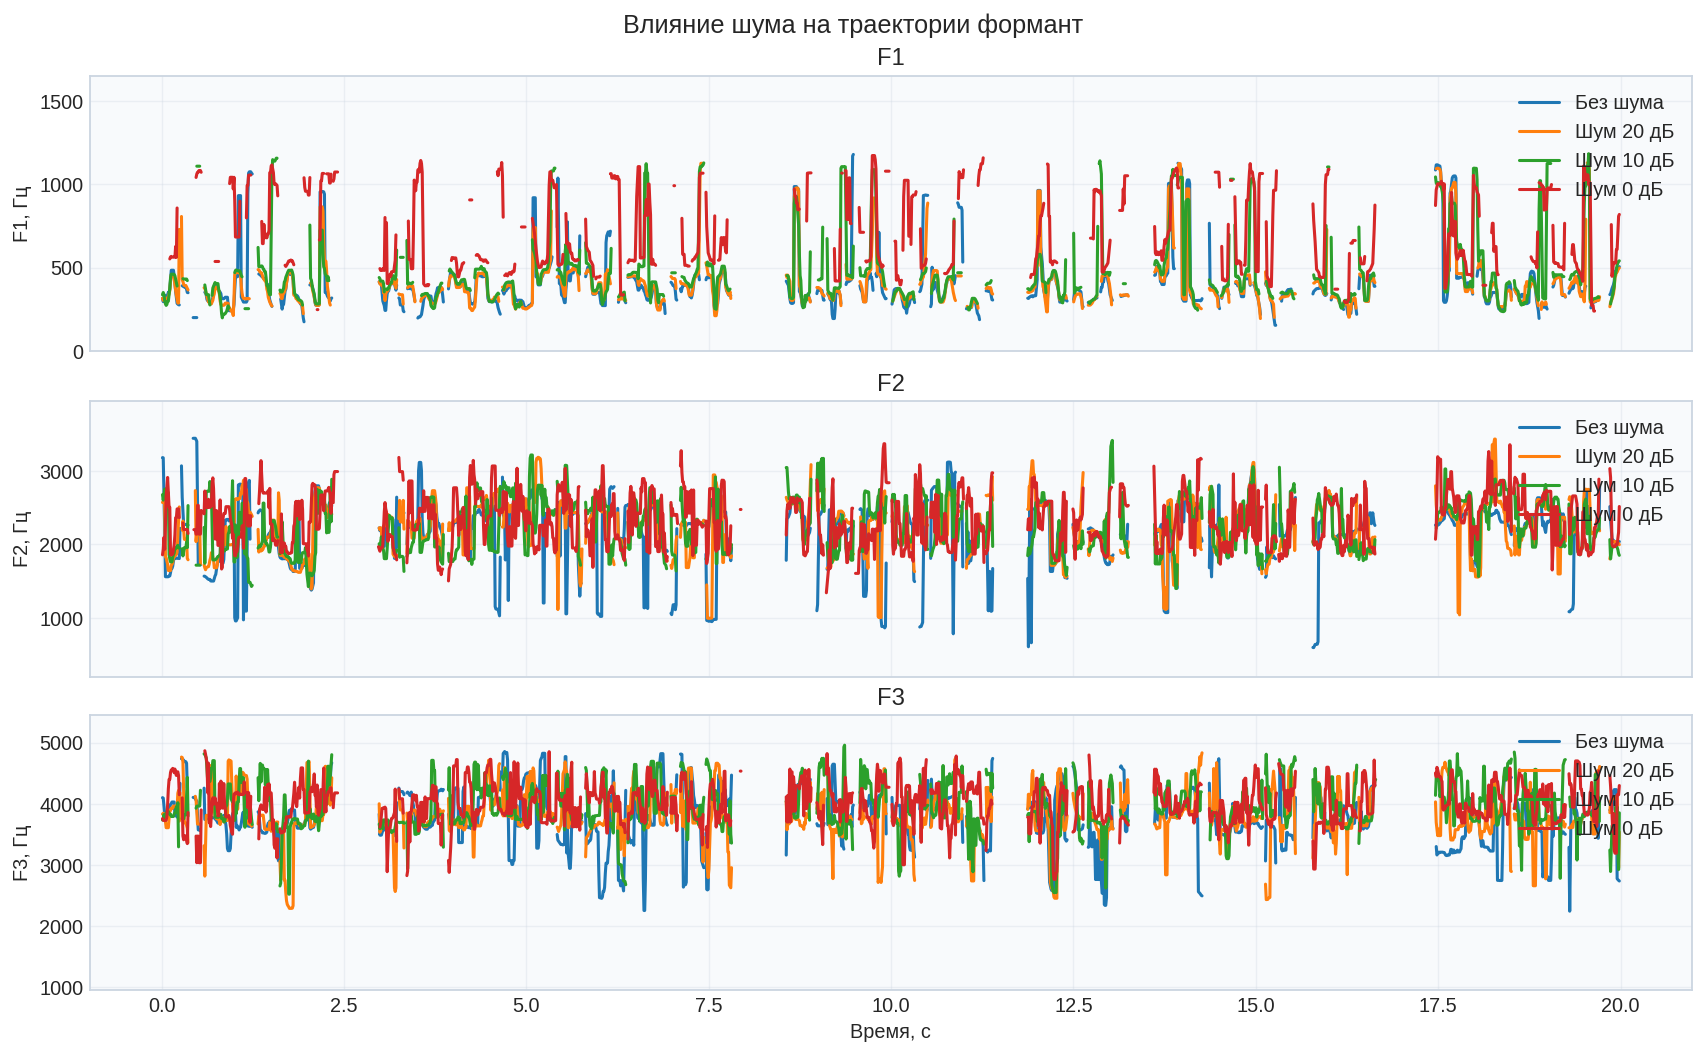

In [9]:
def plot_noise_comparison() -> None:
    fig, axes = plt.subplots(3, 1, figsize=(13, 8.0), sharex=True, constrained_layout=True)

    for ax, name in zip(axes, FORMANT_RANGES):
        for key, result in noise_analysis.items():
            ax.plot(
                result["times"],
                result["smooth"][name],
                lw=1.7,
                label=noise_recordings[key]["label"],
            )
        lo, hi = FORMANT_RANGES[name]
        ax.set_ylim(max(0, lo - 250), hi + 450)
        ax.set_ylabel(f"{name}, Гц")
        ax.set_title(name)
        ax.grid(True, alpha=0.30)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Время, с")
    fig.suptitle("Влияние шума на траектории формант", fontsize=14)
    plt.show()


plot_noise_comparison()

**Вывод по шуму.** При шуме `20 дБ` доля кадров с тремя формантами почти не меняется: `68.67%` без шума и `67.57%` с шумом. При шуме `0 дБ` она падает до `48.65%`. Отклонения тоже растут: для `F1` до `149.58 Гц`, для `F2` до `303.50 Гц`, для `F3` до `396.35 Гц`.

---
## Короткое сравнение методов

В работе основной метод основан на ЛП и корнях многочлена. Это удобно, потому что форманты связаны с резонансами речевого тракта.

Основные шаги написаны вручную: разбиение на кадры, автокорреляция, алгоритм Левинсона-Дурбина, получение корней и отбор `F1`, `F2`, `F3`. `librosa` используется только для чтения звука и построения спектрограммы.

---
## Вывод

В работе построены траектории первых трех формант для обычной речи, шепота, пения и стихотворной речи. Основной расчет сделан методом линейного предсказания: сигнал делится на кадры, для каждого кадра находятся коэффициенты ЛП, затем через корни многочлена определяются формантные частоты.

Для обычной речи медианные значения равны `359.59 Гц`, `2271.05 Гц`, `3761.27 Гц`. Для шепота первая форманта выше: `535.21 Гц`. Для пения первая и третья форманты тоже выше, чем в обычной речи: `481.82 Гц` и `3997.59 Гц`. В стихотворной речи значения ближе к обычной речи, но переходы чаще.

Шумовая проверка показывает, что метод устойчив к слабому шуму, но заметно портится при `0 дБ`. В этом случае доля кадров с найденными `F1`, `F2`, `F3` падает до `48.65%`, а отклонения от исходной записи становятся большими.